Shielding thickness: 0mm
Mean counts: 190.0
Measured std: 14.6349519364369
Theotetical std: 13.784048752090222
Measured - Theoretical std: 0.850903184346679
---------------------------------------
Shielding thickness: 10mm
Mean counts: 127.58333333333333
Measured std: 13.500561155565034
Theotetical std: 11.29527924990495
Measured - Theoretical std: 2.205281905660083
---------------------------------------
Shielding thickness: 20mm
Mean counts: 111.33333333333333
Measured std: 13.206977035803552
Theotetical std: 10.55146119422961
Measured - Theoretical std: 2.6555158415739424
---------------------------------------
Shielding thickness: 30mm
Mean counts: 112.25
Measured std: 10.037429949942366
Theotetical std: 10.594810050208546
Measured - Theoretical std: -0.5573801002661796
---------------------------------------


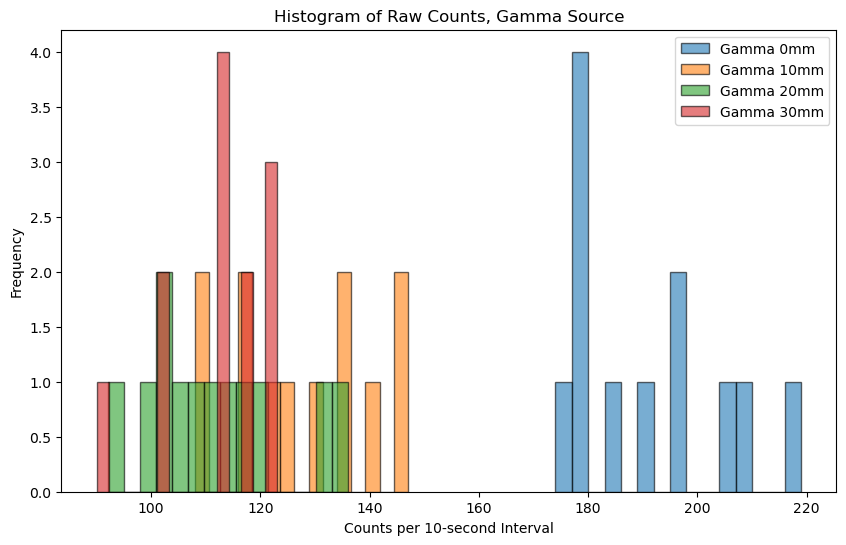

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

# Load data
background = pd.read_csv('data/rad_data/background.csv')
gamma_0 = pd.read_csv('data/rad_data/gamma_no_shield.csv')
gamma_10 = pd.read_csv('data/rad_data/gamma_10mm_WC.csv')
gamma_20 = pd.read_csv('data/rad_data/gamma_20mm_WC.csv')
gamma_30 = pd.read_csv('data/rad_data/gamma_30mm_WC.csv')
beta_0 = pd.read_csv('data/rad_data/beta_no_shield.csv')
beta_2 = pd.read_csv('data/rad_data/beta_2mm_al.csv')
beta_6 = pd.read_csv('data/rad_data/beta_6mm_al.csv')
beta_8 = pd.read_csv('data/rad_data/beta_8mm_al.csv')

measurements = [
    background,
    gamma_0,
    gamma_10,
    gamma_20,
    gamma_30,
    beta_0,
    beta_2,
    beta_6,
    beta_8,
]

columns = [
  'time',
  'cps',
  'totalCount',
  'totalIntervals'
]

#set initial counts and intervals to 0
for measurement in measurements:
    measurement['totalCount'] = measurement['totalCount'] - measurement['totalCount'].iloc[0]
    measurement['totalIntervals'] = measurement['totalIntervals'] - measurement['totalIntervals'].iloc[0]

gamma_list = [gamma_0, gamma_10, gamma_20, gamma_30]
labels = ['0mm', '10mm', '20mm', '30mm']

plt.figure(figsize=(10, 6))

for data, label in zip(gamma_list, labels):
    counts_per_interval = data['totalCount'].diff().dropna()
    
    measured_mean = counts_per_interval.mean()
    measured_std = counts_per_interval.std()
    theoretical_std = np.sqrt(measured_mean)
    # Question 2a
    print('Shielding thickness:', label)
    print('Mean counts:', measured_mean)
    print('Measured std:', measured_std)
    print('Theotetical std:', theoretical_std)
    print('Measured - Theoretical std:', measured_std - theoretical_std)
    print('---------------------------------------')
    
    plt.hist(counts_per_interval, bins=15, alpha=0.6, label=f'Gamma {label}', edgecolor='black')
    

plt.title('Histogram of Raw Counts, Gamma Source')
plt.xlabel('Counts per 10-second Interval')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Question 2
a. The measure means are reasonably close to the theoretical uncertainty.  
b. The mean number of counts decreases as shielding thickness increases.  
(supporting details in print statements above)

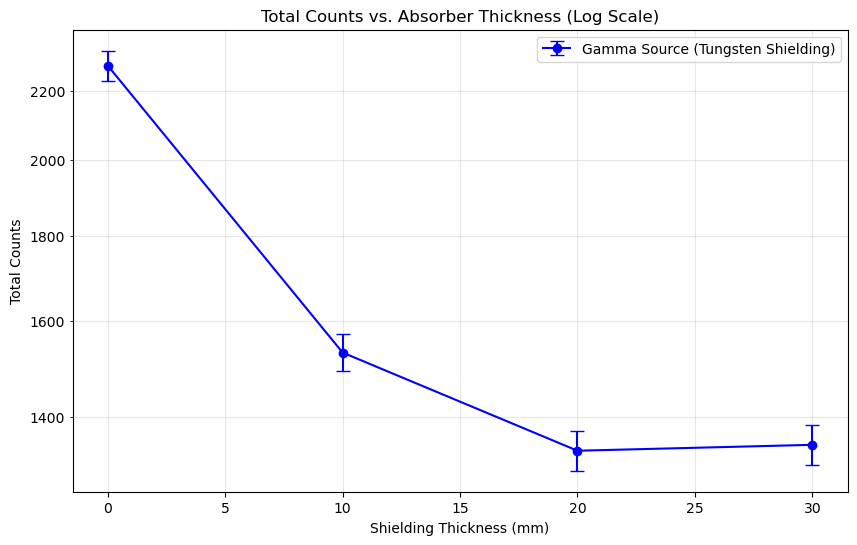

In [2]:
from matplotlib.ticker import ScalarFormatter

gamma_thickness = [0, 10, 20, 30] # mm of Tungsten

gamma_totals = [gamma_0['totalCount'].iloc[-1], 
                gamma_10['totalCount'].iloc[-1], 
                gamma_20['totalCount'].iloc[-1], 
                gamma_30['totalCount'].iloc[-1]]
gamma_errors = np.sqrt(gamma_totals)

plt.figure(figsize=(10, 6))
plt.errorbar(gamma_thickness, gamma_totals, yerr=gamma_errors, 
             fmt='o-', capsize=5, label='Gamma Source (Tungsten Shielding)', color='blue')

plt.yscale('log')
plt.gca().yaxis.set_minor_formatter(ScalarFormatter())

plt.title('Total Counts vs. Absorber Thickness (Log Scale)')
plt.xlabel('Shielding Thickness (mm)')
plt.ylabel('Total Counts')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)

### Question 3
Plot shown above
### Question 4
With a log scale, the trend should be linear. However, there were some errors in data collection, such as slight changes in distance between source and detector when shielding changes were made. This is especially seen in the 30mm measurement. Overall, the counts generally decrease with more shielding which was expected.    
a. Absoption coefficient = 0.03 mm^-1. In the calculation shown below, we excluded the final thickness and found the slope of the linear fit of the remaining measurements.

In [5]:
x = np.array(gamma_thickness[:3]) 
y_log = np.log(gamma_totals[:3])
slope, intercept = np.polyfit(x, y_log, 1)
mu = -slope

print(f'The absorption coefficient is: {mu:.2f} mm^-1')

The absorption coefficient is: 0.03 mm^-1


Shielding thickness: 0mm
Mean counts: 480.5
Measured std: 23.1614884118993
Theotetical std: 21.920310216782973
Measured - Theoretical std: 1.2411781951163263
---------------------------------------
Shielding thickness: 2mm
Mean counts: 297.1666666666667
Measured std: 24.472000079249508
Theotetical std: 17.238522751867883
Measured - Theoretical std: 7.233477327381625
---------------------------------------
Shielding thickness: 6mm
Mean counts: 307.1666666666667
Measured std: 11.574527937229101
Theotetical std: 17.526170907151016
Measured - Theoretical std: -5.951642969921915
---------------------------------------
Shielding thickness: 8mm
Mean counts: 284.3333333333333
Measured std: 19.27001124372618
Theotetical std: 16.862186493255653
Measured - Theoretical std: 2.407824750470528
---------------------------------------


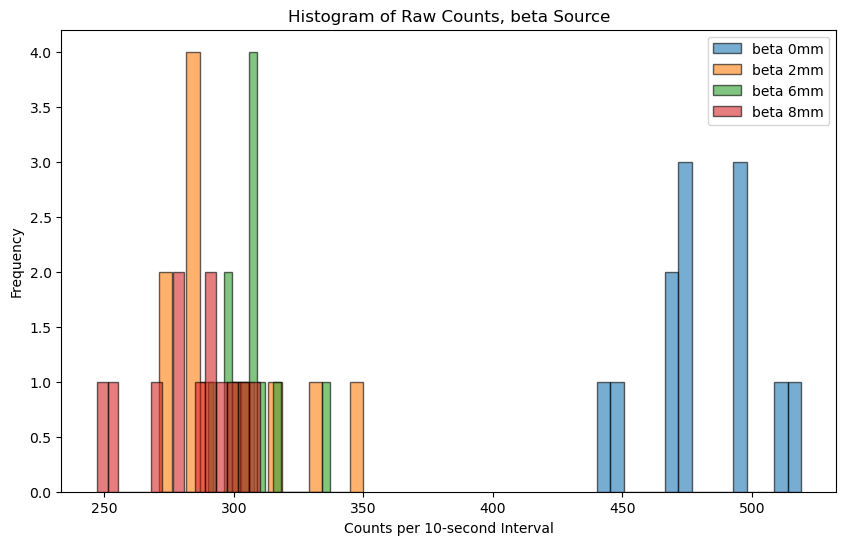

The absorption coefficient is: 0.02 mm^-1


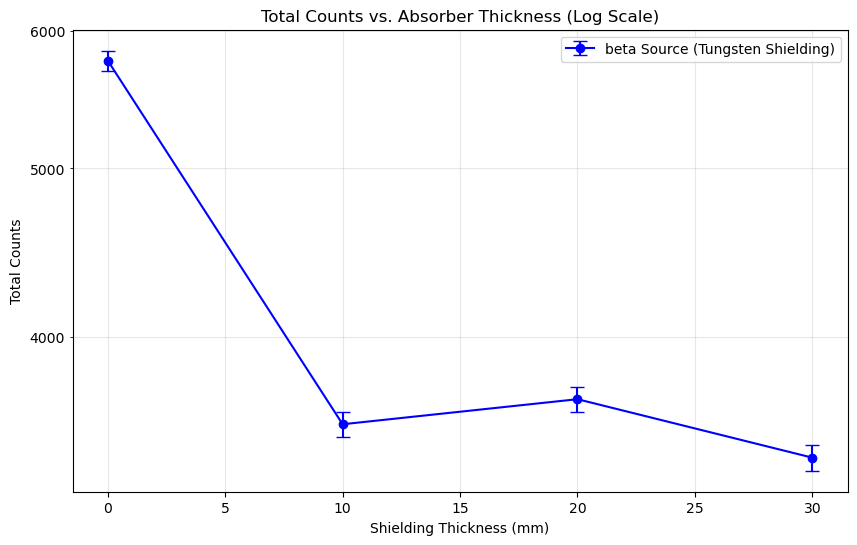

In [6]:
beta_list = [beta_0, beta_2, beta_6, beta_8]
labels = ['0mm', '2mm', '6mm', '8mm']

plt.figure(figsize=(10, 6))

for data, label in zip(beta_list, labels):
    counts_per_interval = data['totalCount'].diff().dropna()
    
    measured_mean = counts_per_interval.mean()
    measured_std = counts_per_interval.std()
    theoretical_std = np.sqrt(measured_mean)
    # Question 2a
    print('Shielding thickness:', label)
    print('Mean counts:', measured_mean)
    print('Measured std:', measured_std)
    print('Theotetical std:', theoretical_std)
    print('Measured - Theoretical std:', measured_std - theoretical_std)
    print('---------------------------------------')
    
    plt.hist(counts_per_interval, bins=15, alpha=0.6, label=f'beta {label}', edgecolor='black')
    

plt.title('Histogram of Raw Counts, beta Source')
plt.xlabel('Counts per 10-second Interval')
plt.ylabel('Frequency')
plt.legend()
plt.show()

from matplotlib.ticker import ScalarFormatter

beta_thickness = [0, 10, 20, 30] # mm of Tungsten

beta_totals = [beta_0['totalCount'].iloc[-1], 
                beta_2['totalCount'].iloc[-1], 
                beta_6['totalCount'].iloc[-1], 
                beta_8['totalCount'].iloc[-1]]
beta_errors = np.sqrt(beta_totals)

plt.figure(figsize=(10, 6))
plt.errorbar(beta_thickness, beta_totals, yerr=beta_errors, 
             fmt='o-', capsize=5, label='beta Source (Tungsten Shielding)', color='blue')

plt.yscale('log')
plt.gca().yaxis.set_minor_formatter(ScalarFormatter())

plt.title('Total Counts vs. Absorber Thickness (Log Scale)')
plt.xlabel('Shielding Thickness (mm)')
plt.ylabel('Total Counts')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)

x = np.array(beta_thickness[:3]) 
y_log = np.log(beta_totals[:3])
slope, intercept = np.polyfit(x, y_log, 1)
mu = -slope

print(f'The absorption coefficient is: {mu:.2f} mm^-1')

### Question 5
We do not expect the absobtion coefficients to be the same because gamma interaction with tungsten is unlikely to be exactly the same as beta interactions with aluminum.